In [1]:
import sys
import os
sys.path.append("/home/karlandersson/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/MasterThesisProject/scripts/heatpipe


In [2]:
import numpy as np
import json

from utils.heatpipe_utils import generate_cfgs_seq, plot_heatpipe_temperature_2d
from utils.solver import Solver

from coupled.heatpipe import Heatpipe
from models.heatpipe.solid_discretised_model import HeatpipeDiscretised

In [3]:
with open("../../data/vapour_data.json", "r") as f:
    data_guoju = json.load(f)
    data = data_guoju["data_guoju_1000"]

In [4]:
ncfgs = 2
Qs = [1e3 for i in range(ncfgs)]
Ns = [[50, 80] for i in range(len(Qs))]
cfgs = generate_cfgs_seq(data, Ns, Qs)

heatpipes = [HeatpipeDiscretised(cfgs[0]), Heatpipe(cfgs[1])]

Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84


In [5]:
solver = Solver(heatpipes)
solver.fsolve()

Running case 1 ...
Running case 2 ...


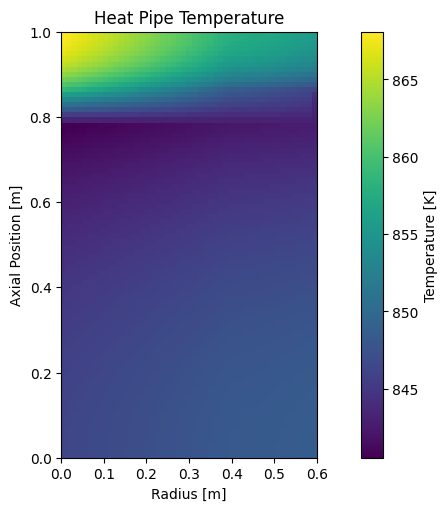

In [6]:
T_solid, mach, T_v = solver.solutions[1]
T_HP = np.c_[T_v, T_solid]

plot_heatpipe_temperature_2d(T_HP, 1, 0.6)

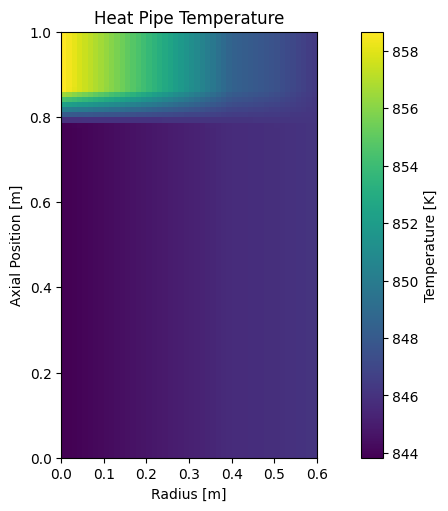

In [7]:
T_HP, T_v = solver.solutions[0]

plot_heatpipe_temperature_2d(T_HP, 1, 0.6)